<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/10_HernandezAlvaro_VisionTransformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Guía de Práctica / Tarea: Clasificación de Alzheimer con un Modelo Híbrido MobileNetV2 + Vision Transformer (ViT)**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 11 de mayo de 2026




## **Objetivo general**
Comprender y replicar un modelo híbrido de clasificación de imágenes médicas que combina **redes convolucionales (CNN)** y **Transformers**, utilizando imágenes de resonancia magnética (MRI) del Alzheimer MRI 4 Classes Dataset.


## **1.	Importar las librerías y preparar el entorno**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.mixed_precision import set_global_policy
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import kagglehub

# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("Error al configurar memoria de GPU:", e)


Memoria de GPU configurada para crecimiento dinámico.


## **2.	Preparación del Dataset**
En esta práctica utilizaremos el dataset Alzheimer MRI 4 Classes, descargado automáticamente desde Kaggle mediante la biblioteca kagglehub.<br>
El dataset contiene cuatro clases:
* NonDemented
*	VeryMildDemented
*	MildDemented
*	ModerateDemented

El código implementa un procedimiento para:
1. Descargar automáticamente el dataset desde Kaggle.
2. Recorrer las carpetas de cada clase.
3. Recolectar todas las rutas de imágenes.
4. Asignar una etiqueta numérica one-hot para cada imagen.
5. Dividir el dataset en entrenamiento y validación con muestreo estratificado.


In [2]:
import os
import json
import kagglehub
from google.colab import userdata

# Usamos credenciales
kaggle_user = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

# Generamos el archivo de autenticación
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": kaggle_user, "key": kaggle_key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("✅ Entorno de Kaggle configurado.")

# Descargamos la copia activa de la base de datos
print("Descargando dataset (backup activo)...")
data_dir = kagglehub.dataset_download("psraju2024/alzheimers-dataset-4-class-of-images")
print(f"✅ ¡Éxito! Dataset descargado en: {data_dir}")

# Mostramos qué carpetas hay dentro para verificar la ruta
carpetas = os.listdir(data_dir)
print(f"📂 Contenido de la carpeta descargada: {carpetas}")

✅ Entorno de Kaggle configurado.
Descargando dataset (backup activo)...


100%|██████████| 34.1M/34.1M [00:02<00:00, 14.0MB/s]

Extracting files...


✅ ¡Éxito! Dataset descargado en: /root/.cache/kagglehub/datasets/psraju2024/alzheimers-dataset-4-class-of-images/versions/2
📂 Contenido de la carpeta descargada: ['Alzheimer_MRI_4_classes_dataset']


In [3]:
from tensorflow.keras.mixed_precision import set_global_policy
import kagglehub
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from google.colab import userdata

# Configuración y descarga
set_global_policy('mixed_float16')
print("Configurando credenciales y descargando dataset...")

kaggle_user = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": kaggle_user, "key": kaggle_key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

data_dir = kagglehub.dataset_download("psraju2024/alzheimers-dataset-4-class-of-images")
print(f"Dataset downloaded to: {data_dir}")

# Mapeo de etiquetas
diagnosis_mapping = {
    0: 'MildDemented',
    1: 'ModerateDemented',
    2: 'NonDemented',
    3: 'VeryMildDemented',
}
dir_to_code = {
    'MildDemented': 0,
    'ModerateDemented': 1,
    'NonDemented': 2,
    'VeryMildDemented': 3,
}

# Recolección de rutas
def get_image_paths_and_labels():
    image_paths=[]
    labels=[]

    images_dir=os.path.join(data_dir, 'Alzheimer_MRI_4_classes_dataset')

    for class_name, class_code in dir_to_code.items():
        class_dir=os.path.join(images_dir, class_name)
        if os.path.exists(class_dir):
            jpg_files=[f for f in os.listdir(class_dir) if f.lower().endswith('.jpg')]
            for file in jpg_files:
                image_paths.append(os.path.join(class_dir, file))
                labels.append(class_code)

    return np.array(image_paths), np.array(labels)

print("\nCollecting image paths and labels...")
image_paths, labels = get_image_paths_and_labels()
unique, counts = np.unique(labels, return_counts=True)

print("\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"Class {diagnosis_mapping[label]}: {count} images")

# División en entrenamiento y validación
train_paths,val_paths,train_labels,val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTraining set: {len(train_paths)} images")
print(f"Validation set: {len(val_paths)} images")

Configurando credenciales y descargando dataset...
Dataset downloaded to: /root/.cache/kagglehub/datasets/psraju2024/alzheimers-dataset-4-class-of-images/versions/2


Class distribution:
Class MildDemented: 896 images
Class ModerateDemented: 64 images
Class NonDemented: 3200 images
Class VeryMildDemented: 2240 images

Training set: 5120 images
Validation set: 1280 images


## **3.	Creación del pipeline de datos con tf.data**

El pipeline de datos se construye con la API tf.data.Dataset, que es la forma recomendada de alimentar eficientemente imágenes a un modelo TensorFlow.<br>
**Componentes clave del pipeline:**<br>
✔ Función `decode_image`<br>
Se encarga de:
* Leer la imagen desde disco.
* Decodificarla como PNG/JPG.
*	Redimensionarla a 160×160.
*	Normalizarla a rango [0,1].
*	Convertir la etiqueta a one-hot.

Este preprocesamiento garantiza que todas las imágenes lleguen al modelo con dimensiones homogéneas y en formato tensorial.<br>
**Dataset de entrenamiento**<br>
Se aplica el siguiente flujo:
1. **from_tensor_slices**: crea un dataset a partir de rutas y etiquetas.
2. **shuffle**: mezcla las muestras para evitar sesgos.
3. **map**: aplica decode_image a cada elemento (preprocesamiento).
4. **cache**: guarda las imágenes ya procesadas para acelerar épocas posteriores.
5. **batch**: agrupa imágenes en lotes de tamaño fijo (64).
6. **prefetch**: permite procesar un batch mientras la GPU entrena con otro.

Dataset de validación<br>
Es similar al de entrenamiento pero **sin shuffle**, para mantener orden estable.


In [4]:
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 64
NUM_CLASSES = len(diagnosis_mapping)

def decode_image(file_path, label):
    img =tf.io.read_file(file_path)
    img =tf.image.decode_png(img, channels=3)
    img =tf.image.resize(img, IMAGE_SIZE)
    img =tf.cast(img, tf.float32) / 255.0
    label =tf.one_hot(label, NUM_CLASSES)
    return img, label

#dataset
#train
train_ds =tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds =train_ds.shuffle(buffer_size=len(train_paths))
train_ds =train_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)#add auto tune for better fetch
train_ds =train_ds.cache()  # cache is fast
train_ds =train_ds.batch(BATCH_SIZE)
train_ds =train_ds.prefetch(tf.data.AUTOTUNE)
#val
val_ds =tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds =val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds =val_ds.cache()
val_ds =val_ds.batch(BATCH_SIZE)
val_ds =val_ds.prefetch(tf.data.AUTOTUNE)

### Mostrar 5 ejemplos de imágenes de cada clase

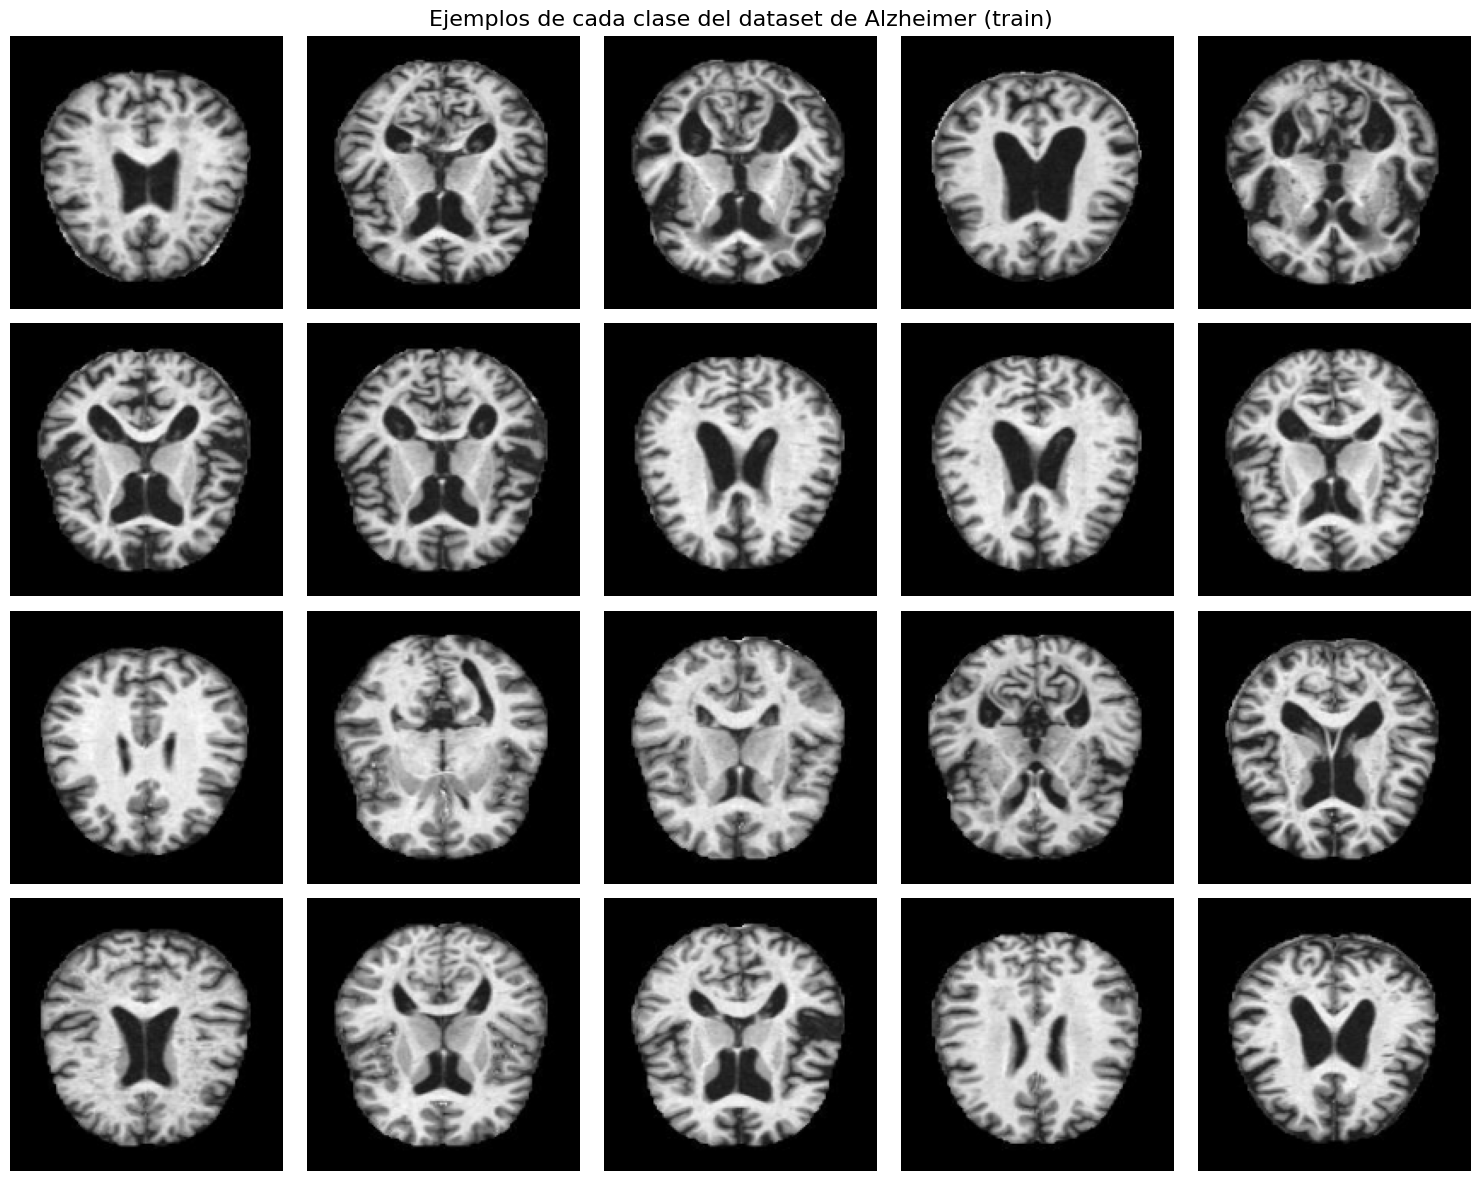

In [5]:
# Número de ejemplos por clase que queremos mostrar
NUM_PER_CLASS = 5

# Diccionario: índice de clase -> lista de imágenes
examples = {i: [] for i in range(NUM_CLASSES)}

# Recorremos el dataset de entrenamiento, des-batcheado
for img, label in train_ds.unbatch():
    # label viene en one-hot, recuperamos el índice de la clase
    class_idx = int(tf.argmax(label).numpy())

    if len(examples[class_idx]) < NUM_PER_CLASS:
        examples[class_idx].append(img.numpy())

    # Si ya tenemos suficientes de todas las clases
    if all(len(v) >= NUM_PER_CLASS for v in examples.values()):
        break

fig, axes = plt.subplots(
    NUM_CLASSES,
    NUM_PER_CLASS,
    figsize=(NUM_PER_CLASS * 3, NUM_CLASSES * 3)
)

fig.suptitle("Ejemplos de cada clase del dataset de Alzheimer (train)", fontsize=16)

for class_idx in range(NUM_CLASSES):
    for j in range(NUM_PER_CLASS):
        ax = axes[class_idx, j] if NUM_CLASSES > 1 else axes[j]
        ax.imshow(examples[class_idx][j])
        ax.axis("off")

        # Solo en la primera columna escribimos el nombre de la clase
        if j == 0:
            ax.set_ylabel(diagnosis_mapping[class_idx], fontsize=12)

plt.tight_layout()
plt.show()

## **4. Arquitectura del Modelo: MobileNetV2 + Vision Transformer**
El modelo final es **híbrido** y combina:
1. **MobileNetV2 como extractor de características (transfer learning)**
* Se carga MobileNetV2 preentrenado en ImageNet.
*	Se elimina su cabeza (include_top=False).
*	Se congelan inicialmente ~90% de sus capas.

MobileNetV2 convierte la imagen 160×160×3 en un mapa de características (por ejemplo 5×5×C), que será la entrada del ViT.

2. **ViTHead: un bloque Transformer personalizado**

Este componente implementa la parte central del Vision Transformer:
* Conversión del mapa H×W×C en una secuencia de tokens.
* Proyección a un espacio de embedding.
*	Adición del token de clase [CLS].
*	Embeddings de posición.
*	Bloques Transformer con:
    *	Multi-Head Attention
    *	MLP
    *	Residuales
    *	LayerNorm
    
El ViTHead devuelve únicamente el vector asociado al token [CLS], que resume toda la imagen.


In [6]:
#ViT Head
class ViTHead(layers.Layer):
    def __init__(self, embed_dim=256, num_heads=4, mlp_dim=512, num_transformer_layers=2, dropout_rate=0.1, **kwargs):
        super(ViTHead, self).__init__(**kwargs)
        self.embed_dim =embed_dim
        self.num_heads= num_heads
        self.mlp_dim =mlp_dim
        self.num_transformer_layers =num_transformer_layers
        self.dropout_rate =dropout_rate

    def build(self, input_shape):
        self.num_patches =input_shape[1] * input_shape[2]  # 5x5
        self.feature_dim =input_shape[3]
        self.projection =layers.Dense(self.embed_dim)#proj
        self.cls_token =self.add_weight(#cls token gen
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="cls_token"
        )#pos-embedding
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embed"
        )
        self.transformer_blocks = []
        for _ in range(self.num_transformer_layers):
            self.transformer_blocks.append([
                layers.LayerNormalization(epsilon=1e-6),
                layers.MultiHeadAttention(#mla
                    num_heads=self.num_heads,
                    key_dim=self.embed_dim // self.num_heads,
                    dropout=self.dropout_rate
                ),
                layers.LayerNormalization(epsilon=1e-6),
                layers.Dense(self.mlp_dim, activation="gelu"),
                layers.Dropout(self.dropout_rate),
                layers.Dense(self.embed_dim)
            ])
        self.layer_norm = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False):
        batch_size =tf.shape(inputs)[0]
        x= tf.reshape(inputs, [batch_size, self.num_patches, self.feature_dim])
        x= self.projection(x)
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])
        x= tf.concat([cls_tokens, x], axis=1)
        x= x + self.pos_embed

        for norm1, attn, norm2, dense1, drop1, dense2 in self.transformer_blocks:
            x_norm =norm1(x)
            attention_output =attn(x_norm, x_norm, x_norm, training=training)
            x=x+attention_output
            x_norm =norm2(x)
            x_mlp =dense1(x_norm)
            x_mlp =drop1(x_mlp, training=training)
            x_mlp= dense2(x_mlp)
            x = x + x_mlp

        x = self.layer_norm(x)
        return x[:, 0]

En este modelo híbrido, el ViT no procesa directamente imágenes crudas, sino la representación abstracta que genera MobileNetV2.
Esto mezcla lo mejor de dos técnicas:
* CNN → excelentemente eficientes al extraer información local.
* Transformers → excelentemente eficientes para integrar relaciones globales.

3. **Capa de clasificación final**

Se agrega:
* Dropout (0.5)
*	Capa Dense con activación softmax → 4 clases.


In [7]:
# Base-model
base_model=MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

#90%freeze next improvement:~80%
layer_n =len(base_model.layers)
freeze =int(layer_n * 0.9)
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= freeze)

#complete model
inputs =layers.Input(shape=(*IMAGE_SIZE, 3))
x =base_model(inputs, training=False)
vit_out =ViTHead(embed_dim=256,
                 num_heads=4,
                 mlp_dim=512,
                 num_transformer_layers=2,
                 dropout_rate=0.1)(x)

x =layers.Dropout(0.5)(vit_out)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=optimizers.Adam(1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"],
              jit_compile=True)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_head (ViTHead)             │ (None, 256)            │     1,389,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,648,580 (13.92 MB)

 Trainable params: 2,432,516 (9.28 MB)

 Non-trainable params: 1,216,064 (4.64 MB)

## 5. Proceso de entrenamiento en dos fases
El entrenamiento se diseña en dos etapas, para aprovechar correctamente el aprendizaje transferido.


**Fase 1 – Entrenamiento de la cabeza nueva (ViT + Dense)**
* Se congela ≈90% del backbone MobileNetV2.
*	Solo las últimas capas de MobileNetV2 y el ViT se entrenan.
*	Tasa de aprendizaje: 1e-4.
*	Callbacks:
  *	**EarlyStopping**: evita sobreajuste.
  *	**ModelCheckpoint**: almacena el mejor modelo de esta fase.

Adaptar primero el ViT y la parte final de MobileNetV2 al nuevo dominio sin modificar demasiado los pesos preentrenados.


In [9]:
early_stop =callbacks.EarlyStopping(monitor="val_accuracy",
                                    patience=10,
                                    restore_best_weights=True)
checkpoint =callbacks.ModelCheckpoint("alzheimer_mobilenet_phase1.keras",
                                      monitor="val_accuracy",
                                      save_best_only=True)

#Phase 1
print("\nPhase 1: Training with frozen base model")#increase epoch next time
history_phase1 = model.fit( train_ds,
                           validation_data=val_ds,
                           epochs=30,
                           callbacks=[early_stop, checkpoint])



Phase 1: Training with frozen base model
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 85s 269ms/step - accuracy: 0.5180 - loss: 1.2146 - val_accuracy: 0.5109 - val_loss: 1.0236
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.6783 - loss: 0.7740 - val_accuracy: 0.5461 - val_loss: 1.0827
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8461 - loss: 0.4005 - val_accuracy: 0.5031 - val_loss: 2.5774
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9252 - loss: 0.2125 - val_accuracy: 0.5016 - val_loss: 3.4784
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9535 - loss: 0.1248 - val_accuracy: 0.5008 - val_loss: 4.8829
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9578 - loss: 0.1222 - val_accuracy: 0.5047 - val_loss: 4.6251
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9852 - loss: 0.0416 - val_accuracy: 0.5375 - val_loss: 3.3595
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.99

**Fase 2 – Fine-tuning del backbone MobileNetV2**

En esta fase se “descongelan” capas adicionales de MobileNetV2:
```
for layer in base_model.layers[freeze:]:
    layer.trainable = True
```
* Tasa de aprendizaje ahora más baja: **1e-5** (para no destruir el conocimiento preentrenado).
* Se recompila el modelo.
* Se entrena hasta 50 épocas (o hasta que detenga EarlyStopping).
*	Se guarda el mejor modelo como "`alzheimer_mobilenet_phase2.keras`".

Ajustar finamente las capas convolucionales preentrenadas para que extraigan características más relevantes específicamente para imágenes de Alzheimer.


In [10]:
# Phase 2
for layer in base_model.layers[freeze:]:
    layer.trainable = True
model.compile(optimizer=optimizers.Adam(1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"],
              jit_compile=True)

print("\nPhase 2: Fine-tuning")
checkpoint_ft = callbacks.ModelCheckpoint("alzheimer_mobilenet_phase2.keras",
                                          monitor="val_loss",
                                          save_best_only=True)
history_phase2 = model.fit( train_ds,
                           validation_data=val_ds,
                           epochs=50,
                           callbacks=[early_stop, checkpoint_ft])



Phase 2: Fine-tuning
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 61s 245ms/step - accuracy: 1.0000 - loss: 1.3362e-04 - val_accuracy: 0.8703 - val_loss: 0.6976
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 1.0000 - loss: 5.8013e-05 - val_accuracy: 0.8680 - val_loss: 0.7873
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 1.0000 - loss: 2.4841e-05 - val_accuracy: 0.8828 - val_loss: 0.7152
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 1.0000 - loss: 2.5739e-05 - val_accuracy: 0.8922 - val_loss: 0.6394
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 1.0000 - loss: 1.6955e-05 - val_accuracy: 0.8969 - val_loss: 0.6111
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 1.0000 - loss: 8.6283e-06 - val_accuracy: 0.9047 - val_loss: 0.5751
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 1.0000 - loss: 7.4069e-06 - val_accuracy: 0.9062 - val_loss: 0.5438
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accura

# **Actividades**

In [12]:
import gc
from google.colab import drive
import os

print("Limpiando la memoria de la GPU del modelo base...")
# Eliminar el modelo anterior de la memoria
tf.keras.backend.clear_session()
gc.collect()

# Montar Drive para guardar la Actividad A
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Alzheimer_ViT_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoints seguros en: {CHECKPOINT_DIR}")

# Confirmar hardware disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    active_device = '/GPU:0'
    print("✅ GPU lista para la Actividad A.")
else:
    active_device = '/CPU:0'
    print("⚠️ GPU agotada. Pasando a CPU automáticamente.")

Limpiando la memoria de la GPU del modelo base...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints seguros en: /content/drive/MyDrive/Alzheimer_ViT_Checkpoints
✅ GPU lista para la Actividad A.


In [13]:
import time

NUM_CLASSES = 4
BATCH_SIZE = 64

def build_dataset_128(image_size, train_paths, train_labels, val_paths, val_labels):
    def decode_image(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, (image_size, image_size))
        img = tf.cast(img, tf.float32) / 255.0
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.shuffle(len(train_paths))
    train_ds = train_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds

def build_model_128(image_size=128, freeze_ratio=0.9):
    base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=(image_size, image_size, 3))
    freeze_until = int(len(base_model.layers) * freeze_ratio)
    for i, layer in enumerate(base_model.layers):
        layer.trainable = (i >= freeze_until)

    inputs = layers.Input(shape=(image_size, image_size, 3))
    x = base_model(inputs, training=False)
    vit_out = ViTHead(embed_dim=256, num_heads=4, mlp_dim=512, num_transformer_layers=2, dropout_rate=0.1)(x)
    x = layers.Dropout(0.5)(vit_out)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs), base_model

In [14]:
IMG_SIZE = 128
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 15

print("\n" + "="*60)
print(f"📐 EJECUTANDO ACTIVIDAD A - IMAGE SIZE = {IMG_SIZE}")
print("="*60)

# 1. Crear nuevo dataset 128x128
train_ds_128, val_ds_128 = build_dataset_128(IMG_SIZE, train_paths, train_labels, val_paths, val_labels)

# 2. Crear nuevo modelo
with tf.device(active_device):
    model_128, base_model_128 = build_model_128(image_size=IMG_SIZE, freeze_ratio=0.9)

    early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
    chkpt_p1 = callbacks.ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'actA_fase1.keras'), monitor="val_accuracy", save_best_only=True)
    chkpt_p2 = callbacks.ModelCheckpoint(os.path.join(CHECKPOINT_DIR, 'actA_fase2.keras'), monitor="val_loss", save_best_only=True)

    # FASE 1 - 128x128
    print("Iniciando Fase 1 (128x128)...")
    model_128.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    historyA_1 = model_128.fit(train_ds_128, validation_data=val_ds_128, epochs=EPOCHS_PHASE1, callbacks=[early_stop, chkpt_p1], verbose=1)

    # FASE 2 - 128x128
    print("Iniciando Fase 2 Fine Tuning (128x128)...")
    for layer in base_model_128.layers:
        layer.trainable = True
    model_128.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    historyA_2 = model_128.fit(train_ds_128, validation_data=val_ds_128, epochs=EPOCHS_PHASE2, callbacks=[early_stop, chkpt_p2], verbose=1)

print(f"\n✅ Actividad A completada. Accuracy final: {max(historyA_2.history['val_accuracy']):.4f}")


📐 EJECUTANDO ACTIVIDAD A - IMAGE SIZE = 128
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Iniciando Fase 1 (128x128)...
Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.5408 - loss: 1.2187 - val_accuracy: 0.5711 - val_loss: 1.0548
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7189 - loss: 0.7108 - val_accuracy: 0.4148 - val_loss: 1.2566
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8717 - loss: 0.3517 - val_accuracy: 0.5031 - val_loss: 1.4787
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9469 - loss: 0.1473 - val_accuracy: 0.6078 - val_loss: 1.1881
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9590 - loss: 0.1091 - val_accuracy: 0.5961 - val_loss: 1.7569
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9764 - loss: 0.0727 - val_accuracy: 0.4430 - val_loss: 2.9571
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9775 - loss: 0.0649 - val_accuracy: 0.5555 - va

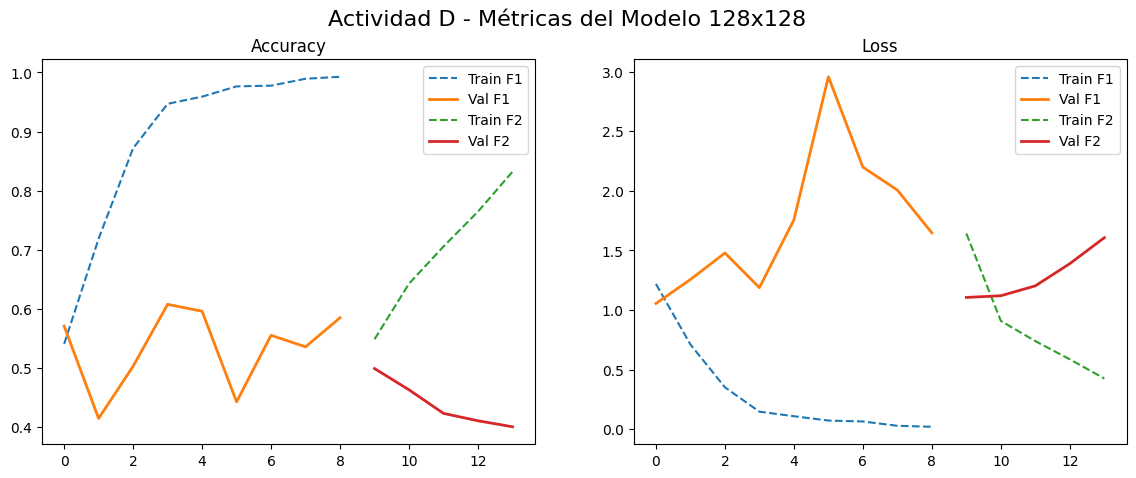


Generando matriz de confusión...


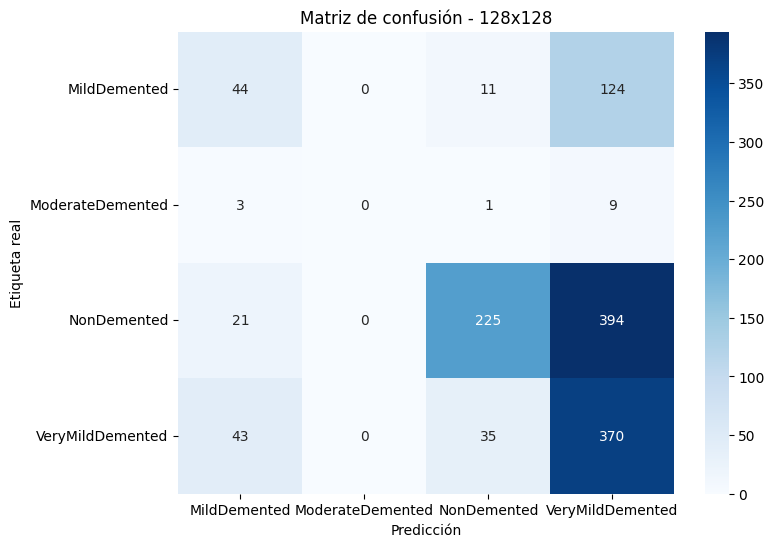

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- GRÁFICAS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actividad D - Métricas del Modelo 128x128', fontsize=16)

# Accuracy
axes[0].plot(historyA_1.history['accuracy'], label='Train F1', linestyle='--')
axes[0].plot(historyA_1.history['val_accuracy'], label='Val F1', linewidth=2)
axes[0].plot([len(historyA_1.history['accuracy']) + i for i in range(len(historyA_2.history['accuracy']))], historyA_2.history['accuracy'], label='Train F2', linestyle='--')
axes[0].plot([len(historyA_1.history['val_accuracy']) + i for i in range(len(historyA_2.history['val_accuracy']))], historyA_2.history['val_accuracy'], label='Val F2', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(historyA_1.history['loss'], label='Train F1', linestyle='--')
axes[1].plot(historyA_1.history['val_loss'], label='Val F1', linewidth=2)
axes[1].plot([len(historyA_1.history['loss']) + i for i in range(len(historyA_2.history['loss']))], historyA_2.history['loss'], label='Train F2', linestyle='--')
axes[1].plot([len(historyA_1.history['val_loss']) + i for i in range(len(historyA_2.history['val_loss']))], historyA_2.history['val_loss'], label='Val F2', linewidth=2)
axes[1].set_title('Loss')
axes[1].legend()
plt.show()

# --- MATRIZ DE CONFUSIÓN ---
print("\nGenerando matriz de confusión...")
y_true = []
y_pred = []

for images, labels in val_ds_128:
    preds = model_128.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=diagnosis_mapping.values(),
            yticklabels=diagnosis_mapping.values())
plt.title('Matriz de confusión - 128x128')
plt.ylabel('Etiqueta real')
plt.xlabel('Predicción')
plt.show()